In [1]:
import os
import re
import numpy as np
import pandas as pd

import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Harshini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Harshini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
DATASET_PATH = "plagiarism_dataset"

print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset path: plagiarism_dataset
Exists: True


In [4]:
text_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(".txt"):
            text_files.append(os.path.join(root, file))

print("Total text files found:", len(text_files))

for file in text_files[:10]:
    print(file)

Total text files found: 12
plagiarism_dataset\student_01.txt
plagiarism_dataset\student_02.txt
plagiarism_dataset\student_03.txt
plagiarism_dataset\student_04.txt
plagiarism_dataset\student_05.txt
plagiarism_dataset\student_06.txt
plagiarism_dataset\student_07.txt
plagiarism_dataset\student_08.txt
plagiarism_dataset\student_09.txt
plagiarism_dataset\student_10.txt


In [6]:
documents = []

for file_path in text_files:
    try:
        with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
            text = file.read()
            
        documents.append({
            "filename": os.path.basename(file_path),
            "filepath": file_path,
            "text": text
        })
        
    except Exception as e:
        print("Error reading:", file_path, e)

df = pd.DataFrame(documents)

print("Number of documents:", len(df))
df.head()

Number of documents: 12


,filename,filepath,text
0,student_01.txt,plagiarism_dataset\student_01.txt,Machine learning is a branch of artificial int...
1,student_02.txt,plagiarism_dataset\student_02.txt,Machine learning is a field of artificial inte...
2,student_03.txt,plagiarism_dataset\student_03.txt,Artificial intelligence has become important i...
3,student_04.txt,plagiarism_dataset\student_04.txt,Data preprocessing is an important stage in a ...
4,student_05.txt,plagiarism_dataset\student_05.txt,Data preprocessing is a necessary step before ...


In [7]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
df["text_length"] = df["text"].apply(len)
df[["filename", "text_length"]].head(10)

(12, 3)
Index(['filename', 'filepath', 'text'], dtype='object')
filename    0
filepath    0
text        0
dtype: int64


,filename,text_length
0,student_01.txt,492
1,student_02.txt,495
2,student_03.txt,507
3,student_04.txt,460
4,student_05.txt,487
5,student_06.txt,469
6,student_07.txt,450
7,student_08.txt,463
8,student_09.txt,482
9,student_10.txt,437


In [8]:
print(df.iloc[0]["text"][:2000])

Machine learning is a branch of artificial intelligence that allows computers to learn patterns from data and make predictions without being explicitly programmed for every task. A machine learning system normally receives training data, extracts useful features, and learns a model from those examples. After training, the model can be evaluated using unseen test data. Common machine learning methods include linear regression, decision trees, support vector machines, and neural networks.



In [9]:
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [10]:
df["cleaned_text"] = df["text"].apply(clean_text)

df[["filename", "cleaned_text"]].head()

,filename,cleaned_text
0,student_01.txt,machine learning is a branch of artificial int...
1,student_02.txt,machine learning is a field of artificial inte...
2,student_03.txt,artificial intelligence has become important i...
3,student_04.txt,data preprocessing is an important stage in a ...
4,student_05.txt,data preprocessing is a necessary step before ...


In [11]:
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    return word_tokenize(text)

df["tokens"] = df["cleaned_text"].apply(tokenize_text)

df[["filename", "tokens"]].head()

,filename,tokens
0,student_01.txt,"[machine, learning, is, a, branch, of, artific..."
1,student_02.txt,"[machine, learning, is, a, field, of, artifici..."
2,student_03.txt,"[artificial, intelligence, has, become, import..."
3,student_04.txt,"[data, preprocessing, is, an, important, stage..."
4,student_05.txt,"[data, preprocessing, is, a, necessary, step, ..."


In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in stop_words
    ]

df["filtered_tokens"] = df["tokens"].apply(remove_stopwords)

df[["filename", "filtered_tokens"]].head()

,filename,filtered_tokens
0,student_01.txt,"[machine, learning, branch, artificial, intell..."
1,student_02.txt,"[machine, learning, field, artificial, intelli..."
2,student_03.txt,"[artificial, intelligence, become, important, ..."
3,student_04.txt,"[data, preprocessing, important, stage, machin..."
4,student_05.txt,"[data, preprocessing, necessary, step, trainin..."


In [13]:
df["processed_text"] = df["filtered_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

df[["filename", "processed_text"]].head()

,filename,processed_text
0,student_01.txt,machine learning branch artificial intelligenc...
1,student_02.txt,machine learning field artificial intelligence...
2,student_03.txt,artificial intelligence become important many ...
3,student_04.txt,data preprocessing important stage machine lea...
4,student_05.txt,data preprocessing necessary step training mac...


In [14]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(df["processed_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (12, 789)


In [15]:
features = vectorizer.get_feature_names_out()

print("Number of features:", len(features))
print(features[:50])

Number of features: 789
['access' 'access attacks' 'access computing' 'according'
 'according demand' 'according importance' 'achieved' 'achieved strong'
 'across' 'across document' 'additional' 'additional entry' 'agriculture'
 'agriculture transportation' 'ai' 'ai focuses' 'algorithm'
 'algorithm common' 'algorithms' 'algorithms careful' 'algorithms improve'
 'algorithms learn' 'allows' 'allows computers' 'also' 'also train'
 'amounts' 'amounts information' 'analysis' 'analysis nlp' 'analyze'
 'analyze data' 'analyze understand' 'applications' 'applications include'
 'applications information' 'appropriate' 'appropriate algorithms'
 'appropriately' 'appropriately careful' 'areas' 'areas computer'
 'artificial' 'artificial intelligence' 'assigns' 'assigns weights'
 'attackers' 'attacks' 'attacks strong' 'attempts']


In [16]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (12, 12)


In [17]:
similarity_percentage = similarity_matrix * 100

print(similarity_percentage)

[[100.          52.67713281   8.2318561    8.57063185   8.05888298
    5.52640098   6.0474663    1.88787996   0.34959013   1.53159031
    5.44422943   7.48391477]
 [ 52.67713281 100.           6.75720935   7.71698204   6.90893692
    3.88761354   6.26810595   1.34242965   0.3552784    2.52615327
    6.34022863   7.72320568]
 [  8.2318561    6.75720935 100.           4.63872205   4.02610282
    5.09941855   4.75697251   2.97989564   0.33668513   2.88818357
    8.07725431   3.40030794]
 [  8.57063185   7.71698204   4.63872205 100.          26.36676199
    4.54694252   3.7882244    1.49800594   0.           1.4653848
    3.39382692   2.60609724]
 [  8.05888298   6.90893692   4.02610282  26.36676199 100.
    5.17006764   5.57879171   0.           0.           1.00223257
    2.77574068   2.36477384]
 [  5.52640098   3.88761354   5.09941855   4.54694252   5.17006764
  100.          17.66122893   0.82674969   1.12276083   1.25761183
    3.92204361   8.88732981]
 [  6.0474663    6.26810595   4

In [18]:
similarity_df = pd.DataFrame(
    similarity_percentage,
    index=df["filename"],
    columns=df["filename"]
)

similarity_df.round(2)

filename,student_01.txt,student_02.txt,student_03.txt,student_04.txt,student_05.txt,student_06.txt,student_07.txt,student_08.txt,student_09.txt,student_10.txt,student_11.txt,student_12.txt
filename,,,,,,,,,,,,
student_01.txt,100.00,52.68,8.23,8.57,8.06,5.53,6.05,1.89,0.35,1.53,5.44,7.48
student_02.txt,52.68,100.00,6.76,7.72,6.91,3.89,6.27,1.34,0.36,2.53,6.34,7.72
student_03.txt,8.23,6.76,100.00,4.64,4.03,5.10,4.76,2.98,0.34,2.89,8.08,3.40
student_04.txt,8.57,7.72,4.64,100.00,26.37,4.55,3.79,1.50,0.00,1.47,3.39,2.61
student_05.txt,8.06,6.91,4.03,26.37,100.00,5.17,5.58,0.00,0.00,1.00,2.78,2.36
student_06.txt,5.53,3.89,5.10,4.55,5.17,100.00,17.66,0.83,1.12,1.26,3.92,8.89
student_07.txt,6.05,6.27,4.76,3.79,5.58,17.66,100.00,0.49,0.00,1.00,4.23,5.67
student_08.txt,1.89,1.34,2.98,1.50,0.00,0.83,0.49,100.00,4.07,2.31,2.07,0.57
student_09.txt,0.35,0.36,0.34,0.00,0.00,1.12,0.00,4.07,100.00,0.00,2.25,0.00


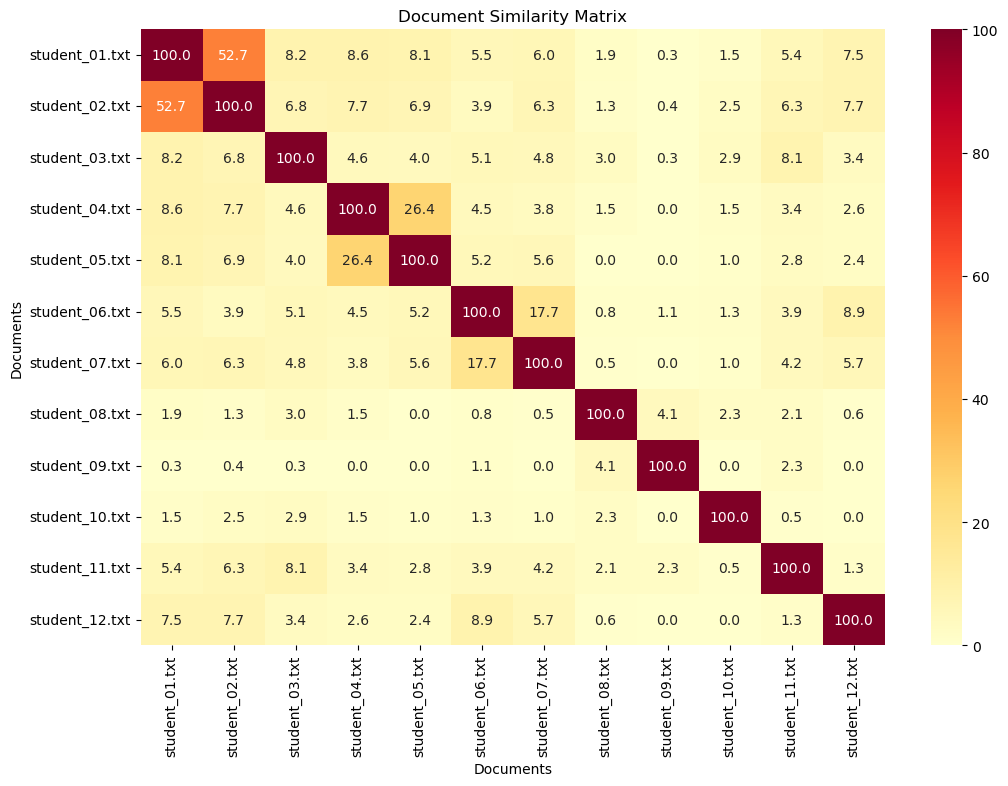

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Document Similarity Matrix")
plt.xlabel("Documents")
plt.ylabel("Documents")

plt.show()

In [20]:
PLAGIARISM_THRESHOLD = 70

print("Plagiarism threshold:", PLAGIARISM_THRESHOLD, "%")

Plagiarism threshold: 70 %


In [21]:
pairs = []

n = len(df)

for i in range(n):
    for j in range(i + 1, n):
        
        score = similarity_percentage[i][j]
        
        pairs.append({
            "Document 1": df.iloc[i]["filename"],
            "Document 2": df.iloc[j]["filename"],
            "Similarity (%)": round(score, 2)
        })

pairs_df = pd.DataFrame(pairs)

pairs_df.head()

,Document 1,Document 2,Similarity (%)
0,student_01.txt,student_02.txt,52.68
1,student_01.txt,student_03.txt,8.23
2,student_01.txt,student_04.txt,8.57
3,student_01.txt,student_05.txt,8.06
4,student_01.txt,student_06.txt,5.53


In [22]:
ranked_pairs = pairs_df.sort_values(
    by="Similarity (%)",
    ascending=False
).reset_index(drop=True)

ranked_pairs.head(20)

,Document 1,Document 2,Similarity (%)
0,student_01.txt,student_02.txt,52.68
1,student_04.txt,student_05.txt,26.37
2,student_06.txt,student_07.txt,17.66
3,student_06.txt,student_12.txt,8.89
4,student_01.txt,student_04.txt,8.57
5,student_01.txt,student_03.txt,8.23
6,student_03.txt,student_11.txt,8.08
7,student_01.txt,student_05.txt,8.06
8,student_02.txt,student_04.txt,7.72
9,student_02.txt,student_12.txt,7.72


In [23]:
def classify_similarity(score):
    
    if score >= 70:
        return "Potential Plagiarism"
    
    elif score >= 50:
        return "Moderate Similarity"
    
    else:
        return "Low Similarity"


ranked_pairs["Status"] = ranked_pairs["Similarity (%)"].apply(
    classify_similarity
)

ranked_pairs.head(20)

,Document 1,Document 2,Similarity (%),Status
0,student_01.txt,student_02.txt,52.68,Moderate Similarity
1,student_04.txt,student_05.txt,26.37,Low Similarity
2,student_06.txt,student_07.txt,17.66,Low Similarity
3,student_06.txt,student_12.txt,8.89,Low Similarity
4,student_01.txt,student_04.txt,8.57,Low Similarity
5,student_01.txt,student_03.txt,8.23,Low Similarity
6,student_03.txt,student_11.txt,8.08,Low Similarity
7,student_01.txt,student_05.txt,8.06,Low Similarity
8,student_02.txt,student_04.txt,7.72,Low Similarity
9,student_02.txt,student_12.txt,7.72,Low Similarity


In [24]:
suspicious_pairs = ranked_pairs[
    ranked_pairs["Similarity (%)"] >= PLAGIARISM_THRESHOLD
]

print("Suspicious pairs found:", len(suspicious_pairs))

suspicious_pairs

Suspicious pairs found: 0


,Document 1,Document 2,Similarity (%),Status


In [25]:
top_10 = ranked_pairs.head(10)

top_10

,Document 1,Document 2,Similarity (%),Status
0,student_01.txt,student_02.txt,52.68,Moderate Similarity
1,student_04.txt,student_05.txt,26.37,Low Similarity
2,student_06.txt,student_07.txt,17.66,Low Similarity
3,student_06.txt,student_12.txt,8.89,Low Similarity
4,student_01.txt,student_04.txt,8.57,Low Similarity
5,student_01.txt,student_03.txt,8.23,Low Similarity
6,student_03.txt,student_11.txt,8.08,Low Similarity
7,student_01.txt,student_05.txt,8.06,Low Similarity
8,student_02.txt,student_04.txt,7.72,Low Similarity
9,student_02.txt,student_12.txt,7.72,Low Similarity


In [26]:
print("=" * 70)
print("        ASSIGNMENT SIMILARITY / PLAGIARISM REPORT")
print("=" * 70)

for _, row in ranked_pairs.head(20).iterrows():
    
    doc1 = row["Document 1"]
    doc2 = row["Document 2"]
    score = row["Similarity (%)"]
    status = row["Status"]
    
    print(f"\n{doc1} vs {doc2}")
    print(f"Similarity: {score}%")
    print(f"Status: {status}")
    print("-" * 70)

        ASSIGNMENT SIMILARITY / PLAGIARISM REPORT

student_01.txt vs student_02.txt
Similarity: 52.68%
Status: Moderate Similarity
----------------------------------------------------------------------

student_04.txt vs student_05.txt
Similarity: 26.37%
Status: Low Similarity
----------------------------------------------------------------------

student_06.txt vs student_07.txt
Similarity: 17.66%
Status: Low Similarity
----------------------------------------------------------------------

student_06.txt vs student_12.txt
Similarity: 8.89%
Status: Low Similarity
----------------------------------------------------------------------

student_01.txt vs student_04.txt
Similarity: 8.57%
Status: Low Similarity
----------------------------------------------------------------------

student_01.txt vs student_03.txt
Similarity: 8.23%
Status: Low Similarity
----------------------------------------------------------------------

student_03.txt vs student_11.txt
Similarity: 8.08%
Status: Low Si

In [27]:
report_df = ranked_pairs.copy()

report_df = report_df[
    [
        "Document 1",
        "Document 2",
        "Similarity (%)",
        "Status"
    ]
]

report_df.head(20)

,Document 1,Document 2,Similarity (%),Status
0,student_01.txt,student_02.txt,52.68,Moderate Similarity
1,student_04.txt,student_05.txt,26.37,Low Similarity
2,student_06.txt,student_07.txt,17.66,Low Similarity
3,student_06.txt,student_12.txt,8.89,Low Similarity
4,student_01.txt,student_04.txt,8.57,Low Similarity
5,student_01.txt,student_03.txt,8.23,Low Similarity
6,student_03.txt,student_11.txt,8.08,Low Similarity
7,student_01.txt,student_05.txt,8.06,Low Similarity
8,student_02.txt,student_04.txt,7.72,Low Similarity
9,student_02.txt,student_12.txt,7.72,Low Similarity


In [28]:
similarity_df.to_csv(
    "similarity_matrix.csv"
)

print("Similarity matrix saved successfully.")

Similarity matrix saved successfully.


In [29]:
report_df.to_csv(
    "plagiarism_report.csv",
    index=False
)

print("Plagiarism report saved successfully.")

Plagiarism report saved successfully.


In [30]:
with pd.ExcelWriter("plagiarism_detection_report.xlsx") as writer:
    
    similarity_df.to_excel(
        writer,
        sheet_name="Similarity Matrix"
    )
    
    report_df.to_excel(
        writer,
        sheet_name="Ranked Pairs",
        index=False
    )
    
    suspicious_pairs.to_excel(
        writer,
        sheet_name="Suspicious Pairs",
        index=False
    )

print("Excel report generated successfully.")

Excel report generated successfully.


In [31]:
def compare_documents(doc1, doc2):
    
    if doc1 not in similarity_df.index:
        print("Document 1 not found.")
        return
    
    if doc2 not in similarity_df.columns:
        print("Document 2 not found.")
        return
    
    score = similarity_df.loc[doc1, doc2]
    
    print("=" * 60)
    print("DOCUMENT COMPARISON")
    print("=" * 60)
    
    print(f"Document 1 : {doc1}")
    print(f"Document 2 : {doc2}")
    print(f"Similarity : {score:.2f}%")
    
    if score >= PLAGIARISM_THRESHOLD:
        print("Result     : ⚠️ Possible Plagiarism")
    else:
        print("Result     : ✅ Low/Acceptable Similarity")

In [32]:
df["filename"].tolist()

['student_01.txt',
 'student_02.txt',
 'student_03.txt',
 'student_04.txt',
 'student_05.txt',
 'student_06.txt',
 'student_07.txt',
 'student_08.txt',
 'student_09.txt',
 'student_10.txt',
 'student_11.txt',
 'student_12.txt']

In [34]:
compare_documents(
    "student_01.txt",
    "student_12.txt"
)

DOCUMENT COMPARISON
Document 1 : student_01.txt
Document 2 : student_12.txt
Similarity : 7.48%
Result     : ✅ Low/Acceptable Similarity


In [35]:
for i in range(len(similarity_df)):
    
    document = similarity_df.index[i]
    
    similarities = similarity_df.iloc[i].copy()
    
    # Remove itself
    similarities[document] = -1
    
    most_similar = similarities.idxmax()
    highest_score = similarities.max()
    
    print(
        f"{document} → {most_similar} "
        f"({highest_score:.2f}%)"
    )

student_01.txt → student_02.txt (52.68%)
student_02.txt → student_01.txt (52.68%)
student_03.txt → student_01.txt (8.23%)
student_04.txt → student_05.txt (26.37%)
student_05.txt → student_04.txt (26.37%)
student_06.txt → student_07.txt (17.66%)
student_07.txt → student_06.txt (17.66%)
student_08.txt → student_09.txt (4.07%)
student_09.txt → student_08.txt (4.07%)
student_10.txt → student_03.txt (2.89%)
student_11.txt → student_03.txt (8.08%)
student_12.txt → student_06.txt (8.89%)


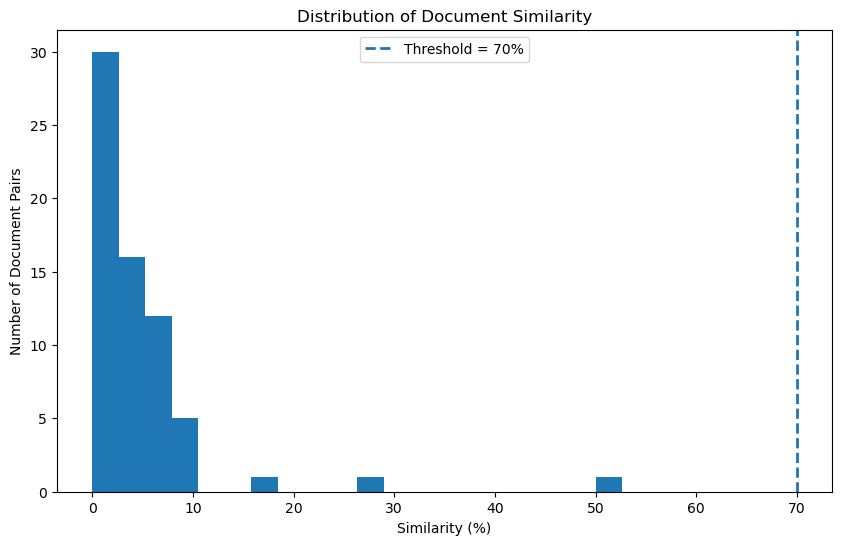

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    ranked_pairs["Similarity (%)"],
    bins=20
)

plt.axvline(
    PLAGIARISM_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {PLAGIARISM_THRESHOLD}%"
)

plt.xlabel("Similarity (%)")
plt.ylabel("Number of Document Pairs")
plt.title("Distribution of Document Similarity")

plt.legend()
plt.show()

In [37]:
status_counts = ranked_pairs["Status"].value_counts()

print(status_counts)

Status
Low Similarity         65
Moderate Similarity     1
Name: count, dtype: int64


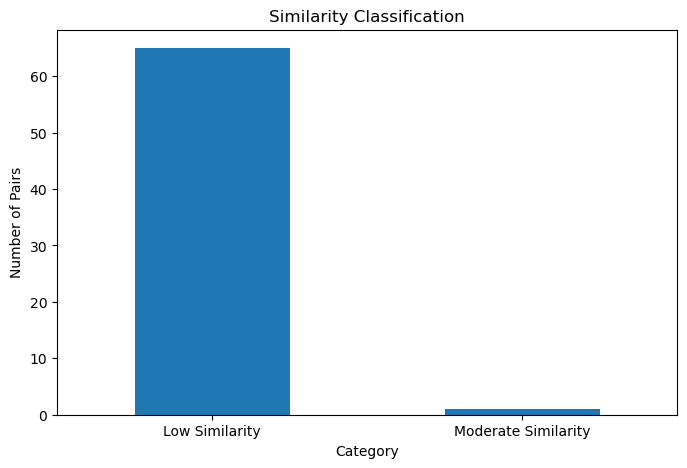

In [38]:
plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Similarity Classification")
plt.xlabel("Category")
plt.ylabel("Number of Pairs")

plt.xticks(rotation=0)

plt.show()